<a href="https://colab.research.google.com/github/nurilhuda05/Pembelajaran_Mesin_2026/blob/main/Kuis1_PembelajaranMesin_Muhammad%20Nuril%20Huda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. PEMAHAMAN DATA (Nuril_244107020004)**

### **1.1 Import Library**

In [364]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### **1.2 Membaca Dataset**

In [365]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Semester 5/PBL/jakarta_house.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **1.3 Menampilkan Data**

In [366]:
df.head()

,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,1,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,3,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,4,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,5,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


### **1.4 Mengetahui Ukuran Dataset**

In [367]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 10000
Jumlah kolom : 9


### **1.5 Menampilkan Nama Kolom**

In [368]:
print('===Nama Kolom===')
for col in df.columns:
    print(col)

===Nama Kolom===
index
price
district
city
bed_rooms
bath_rooms
carport
land_area
building_area


### **1.6 Mengecek Tipe Data**

In [369]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          10000 non-null  int64  
 1   price          10000 non-null  int64  
 2   district       10000 non-null  object 
 3   city           10000 non-null  object 
 4   bed_rooms      10000 non-null  int64  
 5   bath_rooms     10000 non-null  int64  
 6   carport        10000 non-null  int64  
 7   land_area      9997 non-null   float64
 8   building_area  9995 non-null   float64
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB


### **1.7 Mengecek Missing Value**

In [370]:
df.isnull().sum()

,0
index,0
price,0
district,0
city,0
bed_rooms,0
bath_rooms,0
carport,0
land_area,3
building_area,5


### **Mengecek Data Duplikat**

In [371]:
df.duplicated().sum()

print("Jumlah data duplikat :", df.duplicated().sum())

Jumlah data duplikat : 0


# **2. EXPLORATORY DATA ANALYSIS (Nuril_244107020004)**

### **2.1 Statistik Deskriptifk**

In [372]:
df.describe()

,index,price,bed_rooms,bath_rooms,carport,land_area,building_area
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,9997.000000,9995.000000
mean,5000.50000,1.004029e+10,4.253500,3.521300,1.578900,296.610183,319.962481
std,2886.89568,2.004519e+10,3.176609,2.900136,1.743467,502.921686,357.676034
min,1.00000,1.850000e+06,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2500.75000,2.500000e+09,3.000000,2.000000,1.000000,100.000000,139.000000
50%,5000.50000,4.500000e+09,4.000000,3.000000,1.000000,177.000000,230.000000
75%,7500.25000,9.800000e+09,5.000000,4.000000,2.000000,335.000000,400.000000
max,10000.00000,9.000000e+11,63.000000,63.000000,31.000000,17714.000000,15331.000000


### **2.2 Analisis Distribusi Data**

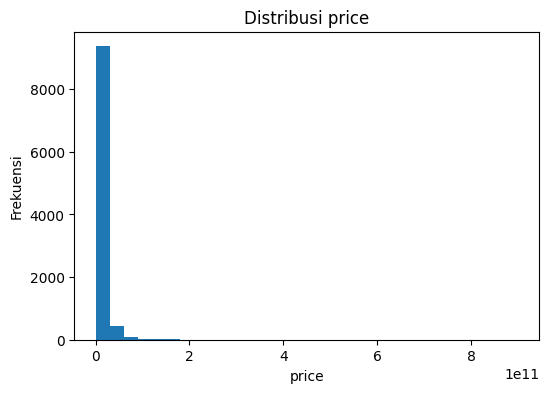

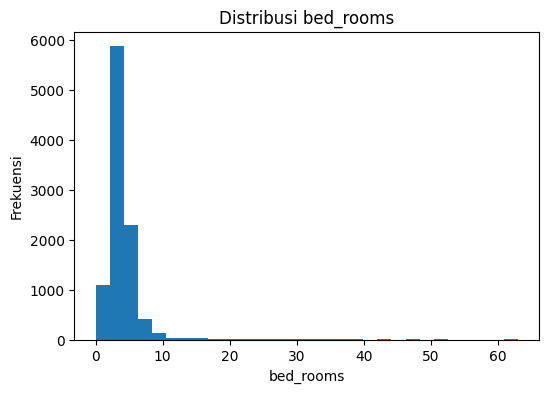

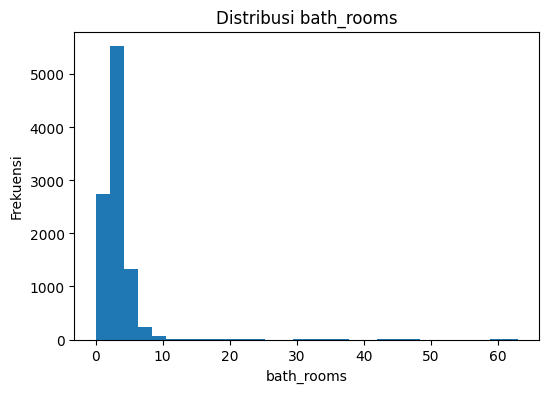

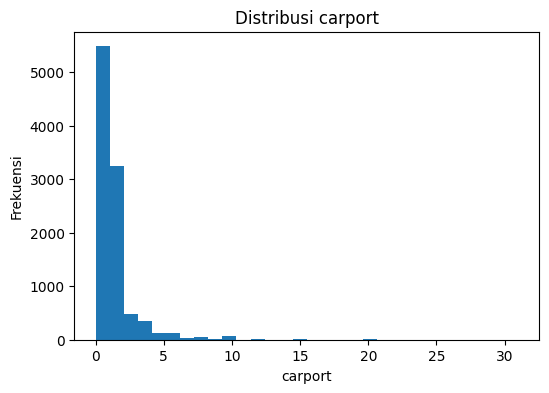

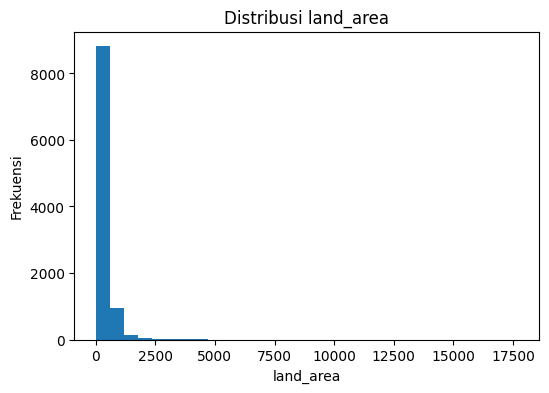

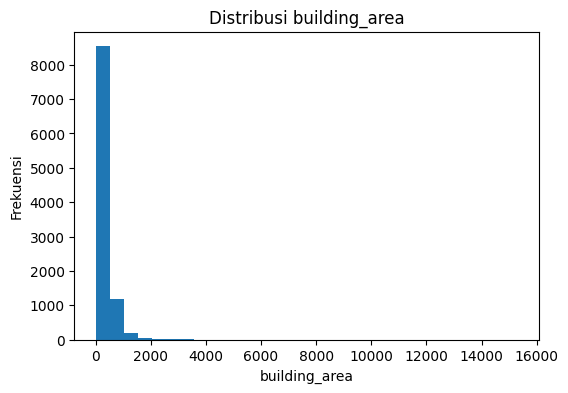

In [373]:
num_cols = [
    'price',
    'bed_rooms',
    'bath_rooms',
    'carport',
    'land_area',
    'building_area'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

### **2.3 Korelasi Antar Fitur**

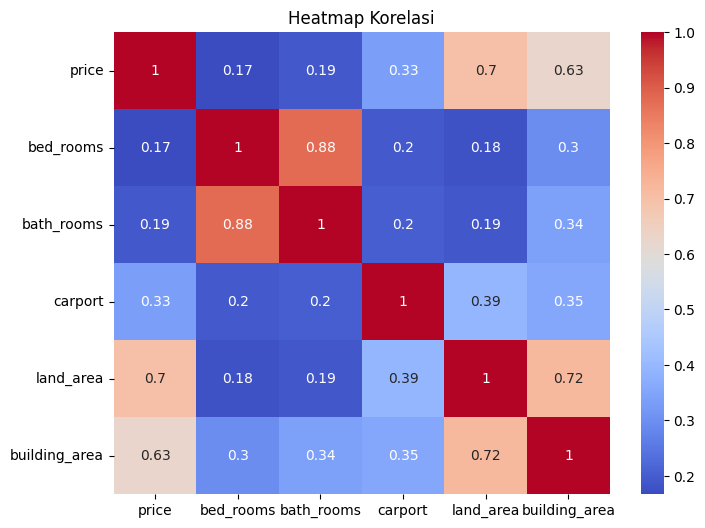

In [374]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Heatmap Korelasi')
plt.show()

# **3. PRA PENGOLAHAN DATA (Nuril_244107020004)**

### **3.1 Data Imputation / Mengisi Missing Value**

In [375]:
# Land Area - Mean
df['land_area'] = df['land_area'].fillna(df['land_area'].mean())

# Building Area - Mean
df['building_area'] = df['building_area'].fillna(df['building_area'].mean())



### **3.2 Validasi Hasil Imputasi**

In [376]:
df.info()

print()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          10000 non-null  int64  
 1   price          10000 non-null  int64  
 2   district       10000 non-null  object 
 3   city           10000 non-null  object 
 4   bed_rooms      10000 non-null  int64  
 5   bath_rooms     10000 non-null  int64  
 6   carport        10000 non-null  int64  
 7   land_area      10000 non-null  float64
 8   building_area  10000 non-null  float64
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB



,0
index,0
price,0
district,0
city,0
bed_rooms,0
bath_rooms,0
carport,0
land_area,0
building_area,0


### **3.3 Deteksi Outlier**

In [377]:
# Menyimpan batas IQR awal
batas_iqr = {}

# Menentukan Kolom Numerik
num_cols = [
    'price',
    'bed_rooms',
    'bath_rooms',
    'carport',
    'land_area',
    'building_area'
]

# Menghitung Nilai Q1, Q3, IQR, Batas Outlier, dan Jumlah Outlier
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    batas_bawah = Q1 - (1.5 * IQR)
    batas_atas = Q3 + (1.5 * IQR)

    # Simpan batas awal
    batas_iqr[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'bawah': batas_bawah,
        'atas': batas_atas
    }

    jumlah_outlier = df[
        (df[col] < batas_bawah) |
        (df[col] > batas_atas)
    ].shape[0]

    print(f"\n===== {col} =====")
    print("Q1 :", Q1)
    print("Q3 :", Q3)
    print("IQR :", IQR)
    print("Batas Bawah :", batas_bawah)
    print("Batas Atas :", batas_atas)
    print("Jumlah Outlier :", jumlah_outlier)


===== price =====
Q1 : 2500000000.0
Q3 : 9800000000.0
IQR : 7300000000.0
Batas Bawah : -8450000000.0
Batas Atas : 20750000000.0
Jumlah Outlier : 1107

===== bed_rooms =====
Q1 : 3.0
Q3 : 5.0
IQR : 2.0
Batas Bawah : 0.0
Batas Atas : 8.0
Jumlah Outlier : 308

===== bath_rooms =====
Q1 : 2.0
Q3 : 4.0
IQR : 2.0
Batas Bawah : -1.0
Batas Atas : 7.0
Jumlah Outlier : 270

===== carport =====
Q1 : 1.0
Q3 : 2.0
IQR : 1.0
Batas Bawah : -0.5
Batas Atas : 3.5
Jumlah Outlier : 795

===== land_area =====
Q1 : 100.0
Q3 : 335.0
IQR : 235.0
Batas Bawah : -252.5
Batas Atas : 687.5
Jumlah Outlier : 881

===== building_area =====
Q1 : 139.0
Q3 : 400.0
IQR : 261.0
Batas Bawah : -252.5
Batas Atas : 791.5
Jumlah Outlier : 656


### **3.4 Penanganan Outlier**

In [378]:
# Menyimpan jumlah data awal
jumlah_awal = len(df)

mask_outlier = pd.Series(False, index=df.index)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    batas_bawah = Q1 - (1.5 * IQR)
    batas_atas = Q3 + (1.5 * IQR)

    mask_outlier |= (
        (df[col] < batas_bawah) |
        (df[col] > batas_atas)
    )

df = df[~mask_outlier]

print("Jumlah data sebelum :", jumlah_awal)
print("Jumlah data sesudah :", len(df))
print("Data yang terhapus :", jumlah_awal - len(df))

Jumlah data sebelum : 10000
Jumlah data sesudah : 8001
Data yang terhapus : 1999


### **3.5 Validasi Hasil Penanganan Outlier**

In [379]:
# Mengecek Jumlah Data Setelah Penghapusan
for col in num_cols:

    batas_bawah = batas_iqr[col]['bawah']
    batas_atas = batas_iqr[col]['atas']

    jumlah_outlier = df[
        (df[col] < batas_bawah) |
        (df[col] > batas_atas)
    ].shape[0]

    print(f"{col} : {jumlah_outlier}")


price : 0
bed_rooms : 0
bath_rooms : 0
carport : 0
land_area : 0
building_area : 0


### **3.6 Visualisasi Distribusi Data Setelah Penghapusan Outlier**

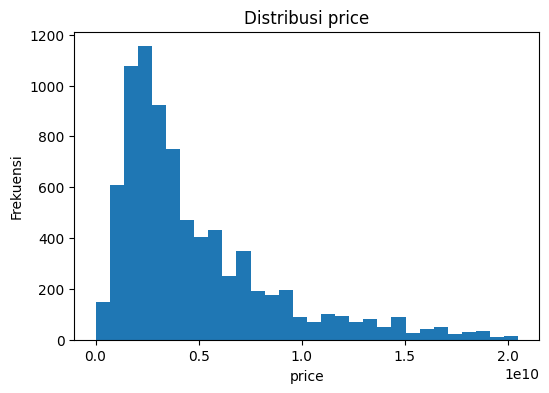

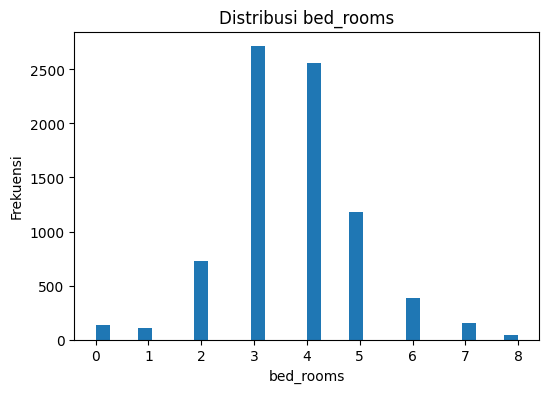

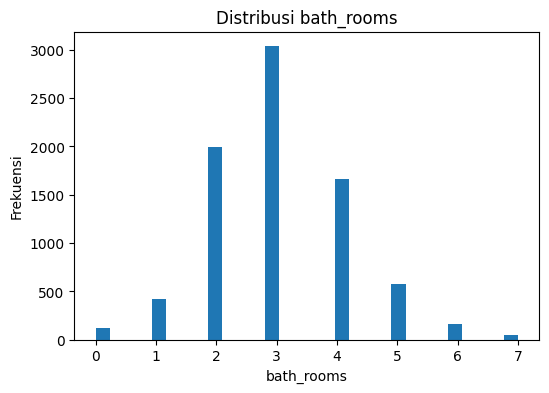

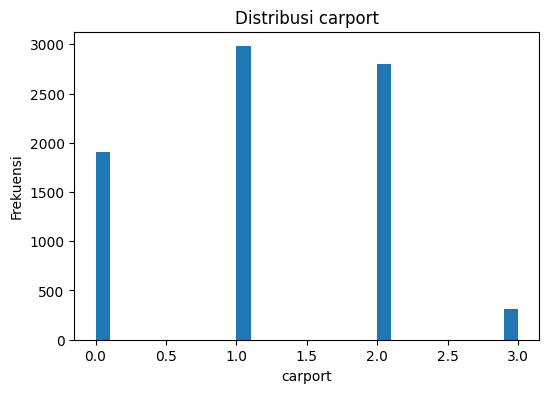

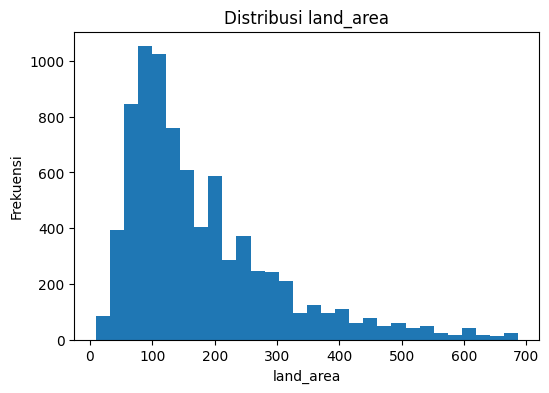

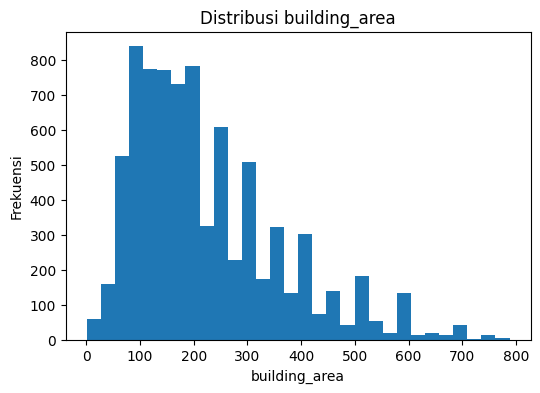

In [380]:
num_cols = [
    'price',
    'bed_rooms',
    'bath_rooms',
    'carport',
    'land_area',
    'building_area'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

### **3.7 Seleksi Fitur**

In [381]:
df = df[
    [
        'price',
        'district',
        'city',
        'bed_rooms',
        'bath_rooms',
        'carport',
        'land_area',
        'building_area'
    ]
]

df.head()

,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


### **3.8 Encoding data kategorikal**

In [382]:
le = LabelEncoder()

# District
df['district'] = le.fit_transform(df['district'])

# City
df['city'] = le.fit_transform(df['city'])

### **3.9 Verifikasi Hasil Encoding**

In [383]:
df[['district', 'city']].head()

,district,city
0,37,0
1,70,0
2,70,0
3,70,0
4,224,0


### **3.10 Standarisasi**

In [384]:
scaler = StandardScaler()

df = pd.DataFrame(scaler.fit_transform(df),columns=df.columns)


print("================ Hasil Setelah Standardisasi ================")
df.head()

================ Hasil Setelah Standardisasi ================


,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,0.289543,-1.108788,-1.292805,-1.344695,0.832897,0.961320,0.589494,0.909454
1,-0.546548,-0.624150,-1.292805,0.240761,-0.888402,-1.413706,-0.643029,0.006448
2,-0.677188,-0.624150,-1.292805,-0.551967,-0.027752,-1.413706,-0.971701,-0.607597
3,-0.755571,-0.624150,-1.292805,-0.551967,-0.888402,-1.413706,-0.971701,-0.752078
4,-0.703315,1.637498,-1.292805,0.240761,-0.027752,-1.413706,-1.004569,-0.838766


# **4. MENENTUKAN JUMLAH CLUSTER (Nuril_244107020004)**

### **4.1 Metode Elbow**

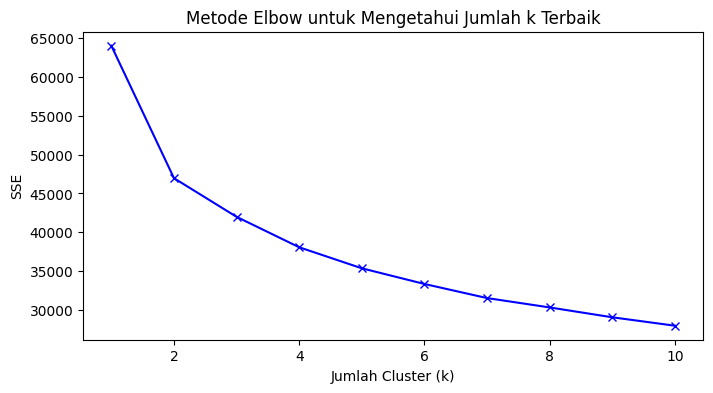

In [385]:
# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1, 11)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(
     n_clusters=k,
     random_state=42
     )
 kmeanModel.fit(df)
 sse.append(kmeanModel.inertia_)

# Plotting SSE
plt.figure(figsize=(8,4))
plt.plot(K, sse, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('SSE')
plt.title('Metode Elbow untuk Mengetahui Jumlah k Terbaik')
plt.show()

### **Menampilkan Nilai SSE Setiap k**

In [386]:
for k, nilai_sse in zip(K, sse):
    print(f'k = {k}, SSE = {nilai_sse:.2f}')

k = 1, SSE = 64008.00
k = 2, SSE = 46967.64
k = 3, SSE = 41992.01
k = 4, SSE = 38076.66
k = 5, SSE = 35370.87
k = 6, SSE = 33353.93
k = 7, SSE = 31539.28
k = 8, SSE = 30335.91
k = 9, SSE = 29067.16
k = 10, SSE = 27983.70


### **Evaluasi Jumlah Cluster Menggunakan Silhouette Score**

In [387]:
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
        )

    labels = kmeans.fit_predict(df)

    score = silhouette_score(
        df,
        labels
    )

    print(f'k = {k}, silhouette = {score:.4f}')

k = 2, silhouette = 0.2724
k = 3, silhouette = 0.1627
k = 4, silhouette = 0.1467
k = 5, silhouette = 0.1588
k = 6, silhouette = 0.1515
k = 7, silhouette = 0.1535
k = 8, silhouette = 0.1518
k = 9, silhouette = 0.1465
k = 10, silhouette = 0.1517


Berdasarkan hasil perhitungan Silhouette Score untuk nilai k = 2 sampai k = 10, diperoleh nilai Silhouette Score tertinggi pada k = 2 yaitu sebesar 0,2724. Nilai ini lebih tinggi dibandingkan nilai k lainnya, sehingga menunjukkan bahwa pembagian data menjadi 2 cluster menghasilkan kualitas cluster yang paling baik. Oleh karena itu, jumlah cluster optimal yang digunakan pada penelitian ini adalah 2 cluster.